# Spam Detection using Machine Learning

## Project Overview

Email spam is a common problem that affects communication and productivity. In this project, we build a machine learning model that classifies SMS messages as either **Spam** or **Ham (Not Spam)**.

The workflow includes:
- Loading the dataset
- Cleaning the data
- Exploratory Data Analysis (EDA)
- Text preprocessing
- Feature extraction
- Model training
- Model evaluation

In [1]:
import numpy as np
import pandas as pd

## Load the Dataset

We load the SMS Spam Collection dataset into a Pandas DataFrame.

The dataset is encoded using **latin-1**, so we specify the encoding to avoid character decoding errors.

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Remove Unnecessary Columns

The dataset contains additional columns that consist entirely of missing values and are not useful for spam classification.

We keep only the first two columns, which contain:
- the message label
- the SMS text

In [3]:
df = df.iloc[:, :2]  #dropping off the NAN columns
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.columns = ['label', 'message']

In [5]:
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [6]:
df.to_csv("spam_cleaned.csv", index=False)

In [7]:
df = pd.read_csv("spam_cleaned.csv")

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   label      5572 non-null   str  
 1   message    5572 non-null   str  
 2   label_num  5572 non-null   int64
dtypes: int64(1), str(2)
memory usage: 130.7 KB


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [8]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r"(http\S+|www\.\S+)", " url ", text)
    text = re.sub(r"\d+", " number ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_message"] = df["message"].apply(clean_text)
df.head()

,label,message,label_num,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",0,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,0,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,free entry in number a wkly comp to win fa cup...
3,ham,U dun say so early hor... U c already then say...,0,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,nah i dont think he goes to usf he lives aroun...


## Split the Dataset into Training and Testing Sets

Before training a machine learning model, it is important to split the dataset into two parts:

- **Training Set (80%)**: Used to train the model and learn patterns from the data.
- **Testing Set (20%)**: Used to evaluate how well the trained model performs on unseen data.

We use `train_test_split()` from Scikit-learn with the following parameters:

- **test_size=0.2**: Allocates 20% of the data for testing.
- **random_state=42**: Ensures the split is reproducible every time the notebook is run.
- **stratify=df["label_num"]**: Preserves the original class distribution (Spam vs. Ham) in both the training and testing sets, preventing class imbalance.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_message"],
    df["label_num"],
    test_size=0.2,
    random_state=42,
    stratify=df["label_num"]
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4457
Test size: 1115


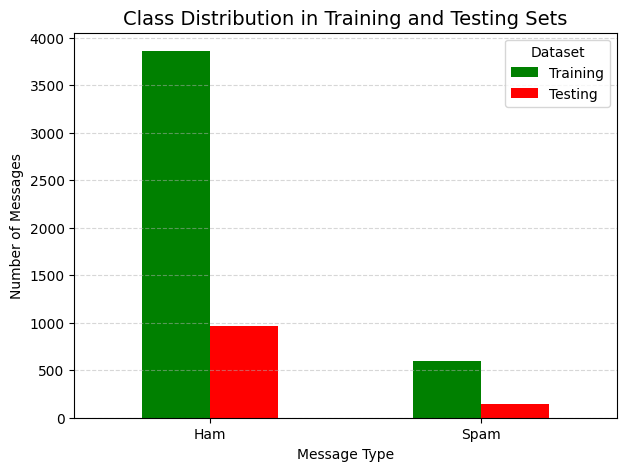

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

distribution = pd.DataFrame({
    "Training": train_counts,
    "Testing": test_counts
})

distribution.index = ["Ham", "Spam"]

ax = distribution.plot(
    kind="bar",
    figsize=(7,5),
    color=["green", "red"]   # Training = Green, Testing = Red
)

plt.title("Class Distribution in Training and Testing Sets", fontsize=14)
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.legend(title="Dataset")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Convert Text into Numerical Features using TF-IDF

Machine learning algorithms cannot process raw text directly. Therefore, we convert the cleaned SMS messages into numerical feature vectors using **Term Frequency–Inverse Document Frequency (TF-IDF)**.

TF-IDF assigns a weight to each word based on:
- **Term Frequency (TF):** How often a word appears in a message.
- **Inverse Document Frequency (IDF):** How unique the word is across the entire dataset.

Words that occur frequently in one message but are rare across all messages receive higher weights, making them more informative for classification.

In this project, we configure the vectorizer to:
- Remove common English stop words.
- Consider both single words (unigrams) and two-word combinations (bigrams).
- Ignore words that appear in fewer than two documents.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2)

X_train_vec = vectorizer.fit_transform(X_train)   # fit_transform on TRAIN only
X_test_vec = vectorizer.transform(X_test)          # transform (no fit) on TEST

print("Vocabulary size:", len(vectorizer.vocabulary_))

Vocabulary size: 7116


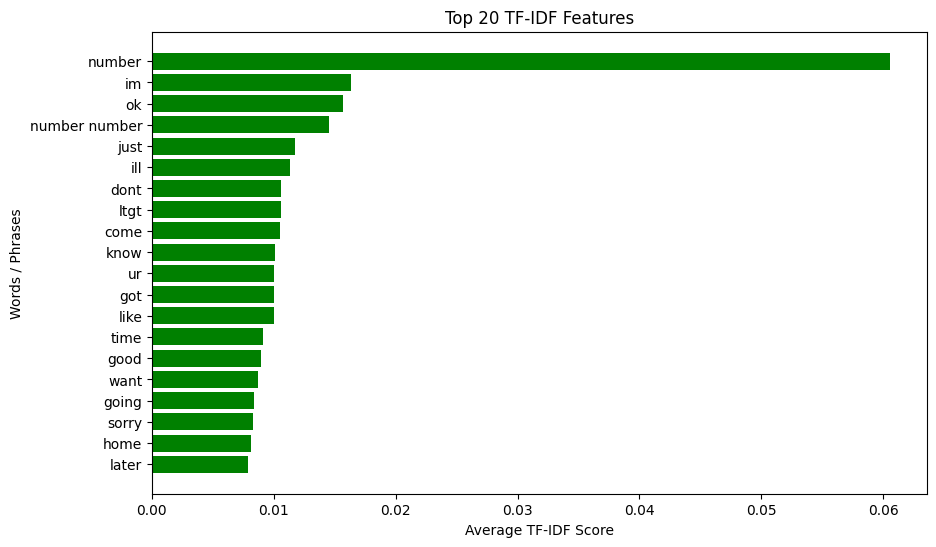

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Calculate average TF-IDF score for each feature
mean_tfidf = np.asarray(X_train_vec.mean(axis=0)).flatten()

# Create DataFrame
tfidf_df = pd.DataFrame({
    "Term": feature_names,
    "TF-IDF Score": mean_tfidf
})

# Top 20 features
top_features = tfidf_df.sort_values(
    by="TF-IDF Score",
    ascending=False
).head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top_features["Term"],
    top_features["TF-IDF Score"],
    color="green"
)

plt.title("Top 20 TF-IDF Features")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Words / Phrases")
plt.gca().invert_yaxis()

plt.show()

## Train the Naive Bayes Classification Model

After converting the text messages into numerical TF-IDF features, the next step is to train a machine learning model.

In this project, we use the **Multinomial Naive Bayes** classifier, which is one of the most effective algorithms for text classification problems such as spam detection.

The model learns the relationship between the TF-IDF features and the corresponding message labels (Ham or Spam). Once trained, it can classify new, unseen messages based on the patterns it has learned.

The smoothing parameter (`alpha=0.3`) is used to prevent zero probabilities for words that appear infrequently in the training data, helping the model generalize better.

In [13]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(alpha=0.3)
model.fit(X_train_vec, y_train)

print("Model trained.")

Model trained.


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

Accuracy : 0.9838565022421525
Precision: 0.9924812030075187
Recall   : 0.8859060402684564
F1       : 0.9361702127659575

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



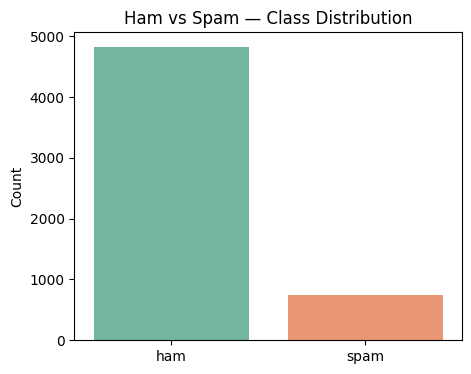

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(x="label", data=df, hue="label", palette="Set2", legend=False)
plt.title("Ham vs Spam — Class Distribution")
plt.xlabel("")
plt.ylabel("Count")
plt.show()

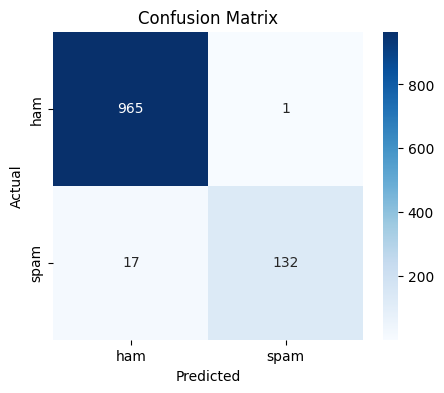

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham","spam"], yticklabels=["ham","spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

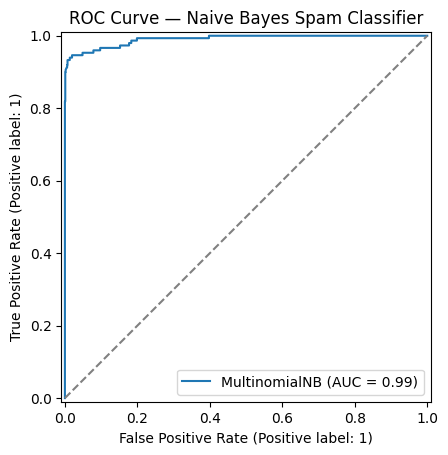

In [17]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test_vec, y_test)
plt.title("ROC Curve — Naive Bayes Spam Classifier")
plt.plot([0,1],[0,1], linestyle="--", color="gray")  # random-guess baseline
plt.show()

## Compare Multiple Machine Learning Models

Rather than relying on a single algorithm, we evaluate the performance of several popular machine learning models for spam detection.

The following models are compared:

- **Multinomial Naive Bayes**
- **Logistic Regression**
- **Linear Support Vector Machine (SVM)**
- **Random Forest**

Each model is trained using the same TF-IDF feature vectors and evaluated on the testing dataset.

To compare their performance fairly, we calculate the following evaluation metrics:

- **Accuracy** – Overall percentage of correct predictions.
- **Precision** – Measures how many messages predicted as spam are actually spam.
- **Recall** – Measures how many actual spam messages are correctly detected.
- **F1-Score** – Harmonic mean of Precision and Recall.
- **Training Time** – Time required to train each model.

The models are then ranked based on their **F1-Score**, which is particularly useful for imbalanced classification problems such as spam detection.

In [18]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.3),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results = []
for name, m in models.items():
    t0 = time.time()
    m.fit(X_train_vec, y_train)
    train_time = time.time() - t0

    pred = m.predict(X_test_vec)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Train time (s)": round(train_time, 3),
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,Train time (s)
2,Linear SVM,0.986547,0.958904,0.939597,0.949153,0.006
0,Multinomial Naive Bayes,0.983857,0.992481,0.885906,0.936170,0.001
3,Random Forest,0.979372,1.000000,0.845638,0.916364,0.884
1,Logistic Regression,0.971300,0.920863,0.859060,0.888889,0.035


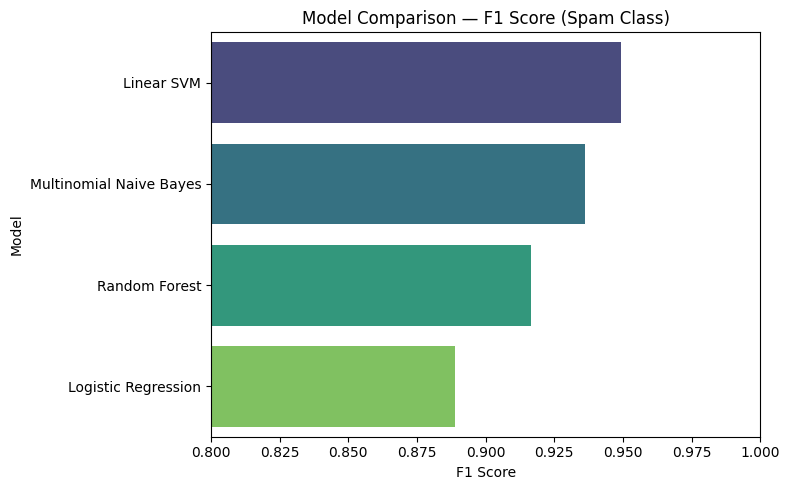

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="F1", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Model Comparison — F1 Score (Spam Class)")
plt.xlim(0.8, 1.0)
plt.xlabel("F1 Score")
plt.tight_layout()
plt.show()

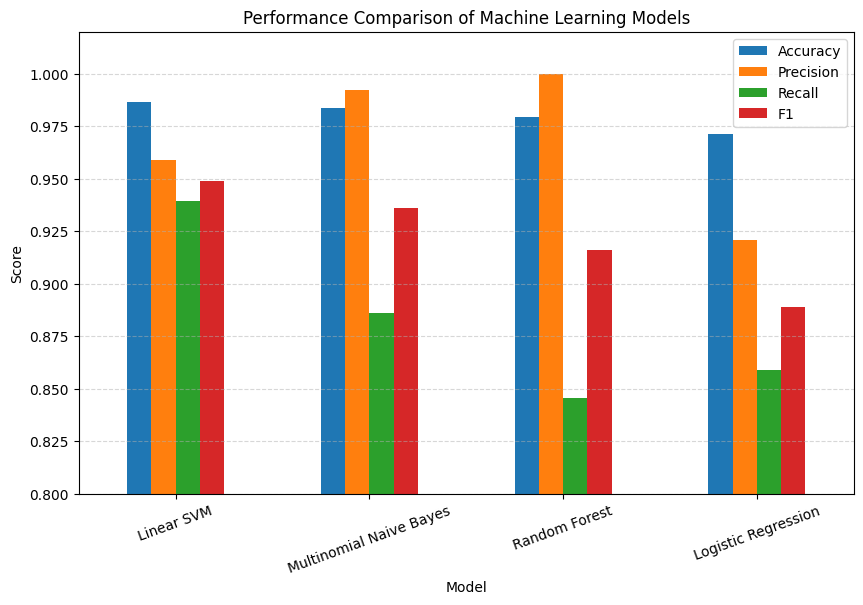

In [20]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0.8, 1.02)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

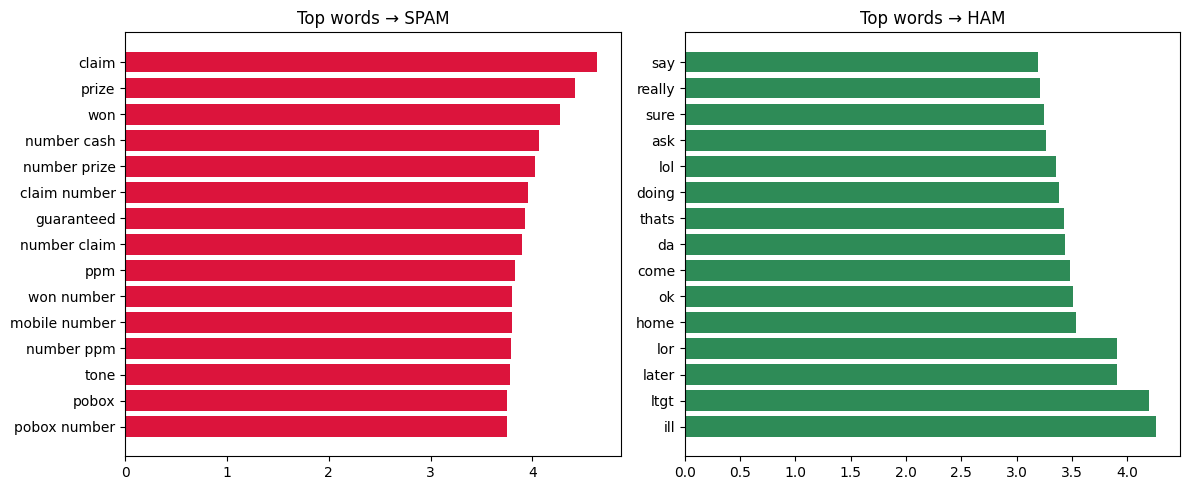

In [21]:
import numpy as np

feature_names = np.array(vectorizer.get_feature_names_out())
log_prob_ham, log_prob_spam = model.feature_log_prob_[0], model.feature_log_prob_[1]
diff = log_prob_spam - log_prob_ham

top_spam_idx = np.argsort(diff)[-15:]
top_ham_idx = np.argsort(diff)[:15]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].barh(feature_names[top_spam_idx], diff[top_spam_idx], color="crimson")
axes[0].set_title("Top words → SPAM")

axes[1].barh(feature_names[top_ham_idx], -diff[top_ham_idx], color="seagreen")
axes[1].set_title("Top words → HAM")

plt.tight_layout()
plt.show()

In [ ]:
def predict_sms(message: str, model=model, vectorizer=vectorizer) -> None:
    clean = clean_text(message)
    vec = vectorizer.transform([clean])
    pred = model.predict(vec)[0]
    prob_spam = model.predict_proba(vec)[0][1]

    label = "🚫 SPAM" if pred == 1 else "✅ HAM (not spam)"
    print(f"Message : {message}")
    print(f"Result  : {label}")
    print(f"Spam probability: {prob_spam:.2%}")

# Try it interactively
while True:
    user_input = input("\nEnter an SMS message (or 'quit' to stop): ")
    if user_input.strip().lower() == "quit":
        break
    predict_sms(user_input)

Message : hi i am aliza
Result  : ✅ HAM (not spam)
Spam probability: 2.83%
